# HARIBON Objective 2 – Transformer Red Tide Risk Prediction

**Goal:** Train a binary-classification Transformer to predict next-day red-tide risk from multi-source oceanographic/atmospheric features.

**Pipeline steps:**
1. Data loading & exploration
2. Data preparation (hybrid_adaptive and native_masking scenarios)
3. Rolling-Origin Cross-Validation with sequence generation
4. Transformer with binary classification
5. Per-split & aggregate metric reporting

**Configuration:** 6 year-based splits, metrics: Accuracy, Precision, Recall, F1-Score, AUC-ROC

In [14]:
# ──────────────────────────────────────────────
# Cell 1 – Imports & Global Configuration
# ──────────────────────────────────────────────
import os, warnings, random, pathlib, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ──
DATA_PATH = os.path.join("..", "final_compiled_dataset", "Combined_Labeled.csv")
MODEL_DIR = os.path.join("saved_model")
RESULTS_DIR = os.path.join("results")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hyper-parameters ──
HISTORY_DAYS = 30          # sequence length (days)
HORIZON    = 1           # predict t+1
EPOCHS     = 40
BATCH_SIZE = 32

# ── Transformer architecture ──
D_MODEL   = 64
NUM_HEADS = 4
NUM_LAYERS = 2
FF_DIM    = 128
DROPOUT   = 0.2

# ── Cross-validation config ──
NUM_SPLITS = 6
TEST_WINDOW_DAYS = 365
MIN_TRAIN_DAYS = 365

# ── Feature list (drop NDVI_raw — 97 % NaN, drop red_tide source column) ──
FEATURES = [
    "CHL", "NDVI_daily", "mlotst", "precip_mm_day",
    "so", "thetao", "uo", "vo",
    "wind_speed_ms", "wind_u_ms", "wind_v_ms",
]
TARGET = "red_tide_label"

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

PyTorch 2.10.0+cpu
CUDA available: False
Features (11): ['CHL', 'NDVI_daily', 'mlotst', 'precip_mm_day', 'so', 'thetao', 'uo', 'vo', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms']


## 1 · Data Loading & Initial Exploration

In [15]:
# ──────────────────────────────────────────────
# Cell 2 – Load & quick-look
# ──────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df_raw.sort_values(["Location_Name", "Date"], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

print("Shape:", df_raw.shape)
print("Locations:", df_raw["Location_Name"].nunique())
print("\n── Label distribution (raw) ──")
print(df_raw["red_tide_label"].value_counts(dropna=False))
print("\n── NaN per column ──")
print(df_raw.isnull().sum())
print("\n── Date range ──")
print(df_raw["Date"].min(), "→", df_raw["Date"].max())

Shape: (28511, 16)
Locations: 7

── Label distribution (raw) ──
red_tide_label
0.000    23031
1.000     4801
NaN        495
0.800       30
0.500       28
0.650       24
0.550       21
0.600       21
0.700       21
0.750       21
0.560        3
0.620        3
0.680        3
0.740        3
0.575        3
0.725        3
Name: count, dtype: int64

── NaN per column ──
Location_Name         0
red_tide          26089
Date                  0
CHL                 168
NDVI_daily        10135
NDVI_raw          27705
mlotst              441
precip_mm_day       245
so                  441
thetao              441
uo                  441
vo                  441
wind_speed_ms        77
wind_u_ms            77
wind_v_ms            77
red_tide_label      495
dtype: int64

── Date range ──
2015-01-01 00:00:00 → 2026-02-24 00:00:00


## 2 · Hybrid Gap-Adaptive Imputation

| Gap length | Strategy |
|---|---|
| **< 7 days** (micro) | Linear interpolation (time-based) |
| **7 – 30 days** (block) | Polynomial interpolation (order 2) |
| **> 30 days** (seasonal / long) | Climatological mean (month-day average for that location across all years) |

Imputation is applied **per location, per feature column** and adapts to gap length for optimal reconstruction.

Two scenarios evaluated:
- **`hybrid_adaptive`**: uses XGBoost-compatible gap-type adaptive imputation (matches other models)
- **`native_masking`**: no imputation; model handles missingness with explicit indicators

In [16]:
# ──────────────────────────────────────────────
# Cell 3 – Data Preparation Functions
# ──────────────────────────────────────────────

def _to_binary_label(series: pd.Series, threshold: float = 0.5) -> pd.Series:
    """Convert red_tide_label to binary class with configurable threshold."""
    numeric = pd.to_numeric(series, errors="coerce")
    return (numeric >= threshold).astype(float)

def _feature_columns(df: pd.DataFrame) -> list[str]:
    NON_FEATURE_COLS = {"Location_Name", "Date", "red_tide", "red_tide_label", "target_label"}
    cols = []
    for c in df.columns:
        if c in NON_FEATURE_COLS:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

def _identify_nan_gaps(series: pd.Series) -> list[dict]:
    """Return a list of dicts describing contiguous NaN blocks.
    Each dict: {'start': int, 'end': int, 'length': int}  (iloc positions).
    """
    is_nan = series.isna().values
    gaps = []
    i = 0
    while i < len(is_nan):
        if is_nan[i]:
            start = i
            while i < len(is_nan) and is_nan[i]:
                i += 1
            gaps.append({"start": start, "end": i - 1, "length": i - start})
        else:
            i += 1
    return gaps


def _climatological_mean(loc_df: pd.DataFrame, col: str) -> pd.Series:
    """Month-Day average across all years for *col* within one location."""
    loc_df = loc_df.copy()
    loc_df["_md"] = loc_df["Date"].dt.strftime("%m-%d")
    clim = loc_df.groupby("_md")[col].transform("mean")
    return clim


def _hybrid_gap_adaptive_impute_location(
    loc_df: pd.DataFrame,
    feature_cols: list[str],
) -> pd.DataFrame:
    """
    Hybrid gap-adaptive imputation per location.
    
    Strategy per gap length:
      micro  (< 7 days)  → linear interpolation (time-based)
      block  (7-30 days) → polynomial interpolation (order=2)
      long   (> 30 days) → climatological mean (month-day avg per location)
    """
    loc_df = loc_df.copy()
    loc_df = loc_df.sort_values("Date").reset_index(drop=True)

    for col in feature_cols:
        ts = pd.to_numeric(loc_df[col], errors="coerce")
        if ts.isna().sum() == 0:
            continue

        gaps = _identify_nan_gaps(ts)
        if not gaps:
            continue

        # Pre-compute climatological fill for this column / location
        clim_fill = _climatological_mean(loc_df, col)

        for gap in gaps:
            g_len = gap["length"]
            gap_iloc = slice(gap["start"], gap["end"] + 1)

            if g_len < 7:
                # Micro gap → linear interpolation (time-based)
                ts = ts.interpolate(method="linear", limit_direction="both")
            elif g_len <= 30:
                # Block gap → polynomial order-2
                ts = ts.interpolate(method="polynomial", order=2, limit_direction="both")
            else:
                # Long / seasonal gap → climatological mean
                ts.iloc[gap_iloc] = clim_fill.iloc[gap_iloc]

        # Final safety net: any remaining NaN filled with forward-fill then back-fill
        ts = ts.ffill().bfill()
        
        loc_df[col] = ts

    return loc_df


def prepare_scenario_dataframe(
    base_df: pd.DataFrame,
    scenario: str,
    label_threshold: float = 0.5,
) -> pd.DataFrame:
    """Prepare model-ready frame for one scenario."""
    if scenario not in {"hybrid_adaptive", "native_masking"}:
        raise ValueError(f"Unsupported scenario: {scenario}")

    df = base_df.copy()
    feat_cols = _feature_columns(df)

    for col in feat_cols:
        df[f"is_missing_{col}"] = pd.to_numeric(df[col], errors="coerce").isna().astype(int)

    if scenario == "hybrid_adaptive":
        chunks = []
        for _, loc_df in df.groupby("Location_Name", sort=False):
            chunks.append(
                _hybrid_gap_adaptive_impute_location(
                    loc_df,
                    feat_cols,
                )
            )
        df = pd.concat(chunks, axis=0).sort_values(["Location_Name", "Date"]).reset_index(drop=True)

    location_ohe = pd.get_dummies(df["Location_Name"], prefix="loc", dtype=float)
    df = pd.concat([df, location_ohe], axis=1)

    df["target_label"] = _to_binary_label(df["red_tide_label"], threshold=label_threshold)
    df = df[pd.to_numeric(df["red_tide_label"], errors="coerce").notna()].copy()
    df = df.sort_values(["Location_Name", "Date"]).reset_index(drop=True)
    return df

# ── Run imputation ──
print("NaN BEFORE imputation:")
print(df_raw[FEATURES].isnull().sum())

print("\nPreparing hybrid_adaptive scenario...")
df_hybrid = prepare_scenario_dataframe(df_raw, "hybrid_adaptive")
print(f"Hybrid shape: {df_hybrid.shape}")

print("\nNaN AFTER imputation:")
feat_cols = _feature_columns(df_hybrid)
print(df_hybrid[feat_cols].isnull().sum())

print("\nPreparing native_masking scenario...")
df_native = prepare_scenario_dataframe(df_raw, "native_masking")
print(f"Native shape: {df_native.shape}")

SCENARIOS_DATA = {
    "hybrid_adaptive": df_hybrid,
    "native_masking": df_native,
}

NaN BEFORE imputation:
CHL                168
NDVI_daily       10135
mlotst             441
precip_mm_day      245
so                 441
thetao             441
uo                 441
vo                 441
wind_speed_ms       77
wind_u_ms           77
wind_v_ms           77
dtype: int64

Preparing hybrid_adaptive scenario...
Hybrid shape: (28016, 36)

NaN AFTER imputation:
CHL                         0
NDVI_daily                  0
NDVI_raw                    0
mlotst                      0
precip_mm_day               0
so                          0
thetao                      0
uo                          0
vo                          0
wind_speed_ms               0
wind_u_ms                   0
wind_v_ms                   0
is_missing_CHL              0
is_missing_NDVI_daily       0
is_missing_NDVI_raw         0
is_missing_mlotst           0
is_missing_precip_mm_day    0
is_missing_so               0
is_missing_thetao           0
is_missing_uo               0
is_missing_vo          

## 3 · Rolling-Origin Cross-Validation

Generate 6 year-based splits to match GRU/LSTM models.

In [17]:
# ──────────────────────────────────────────────
# Cell 4 – Rolling-Origin Splits
# ──────────────────────────────────────────────

from dataclasses import dataclass
from typing import List

@dataclass
class RollingSplit:
    split_num: int
    cutoff_date: pd.Timestamp
    test_start: pd.Timestamp
    test_end: pd.Timestamp

def generate_rolling_origin_splits(
    labeled_df: pd.DataFrame,
    num_splits: int = 6,
    test_window_days: int = 365,
    min_train_days: int = 365,
) -> List[RollingSplit]:
    """Generate rolling-origin splits from available labeled dates."""
    unique_dates = np.array(sorted(labeled_df["Date"].dropna().unique()))

    if len(unique_dates) < (min_train_days + test_window_days + 1):
        raise ValueError(
            f"Not enough dated rows for requested split config: "
            f"need at least {min_train_days + test_window_days + 1} unique dates, "
            f"got {len(unique_dates)}"
        )

    splits = []
    for i in range(num_splits):
        # Start from the end and work backwards
        test_end_idx = len(unique_dates) - 1 - i
        test_start_idx = test_end_idx - test_window_days + 1

        if test_start_idx < 0:
            break

        test_start = pd.Timestamp(unique_dates[test_start_idx])
        test_end = pd.Timestamp(unique_dates[test_end_idx])

        # Ensure we have enough training data
        train_end_idx = test_start_idx - 1
        if train_end_idx < min_train_days:
            break

        cutoff_date = pd.Timestamp(unique_dates[train_end_idx])

        splits.append(RollingSplit(
            split_num=i + 1,
            cutoff_date=cutoff_date,
            test_start=test_start,
            test_end=test_end,
        ))

    return splits[::-1]  # Reverse to get chronological order

# Generate splits for both scenarios
# Use year-based splits to match GRU/LSTM
year_splits = [
    (2019, [2020]),
    (2020, [2021]),
    (2021, [2022]),
    (2022, [2023]),
    (2023, [2024]),
    (2024, [2025, 2026]),
]

splits = []
for i, (train_end_yr, test_yrs) in enumerate(year_splits, 1):
    # Convert year-based split to RollingSplit
    cutoff_date = pd.Timestamp(f"{train_end_yr}-12-31")
    test_start = pd.Timestamp(f"{min(test_yrs)}-01-01")
    test_end = pd.Timestamp(f"{max(test_yrs)}-12-31")
    
    splits.append(RollingSplit(
        split_num=i,
        cutoff_date=cutoff_date,
        test_start=test_start,
        test_end=test_end,
    ))

print(f"Generated {len(splits)} year-based splits:")
for split in splits:
    test_years = [split.test_start.year] if split.test_start.year == split.test_end.year else list(range(split.test_start.year, split.test_end.year + 1))
    print(f"  Split {split.split_num}: Train ≤ {split.cutoff_date.year} | Test {test_years}")

Generated 6 year-based splits:
  Split 1: Train ≤ 2019 | Test [2020]
  Split 2: Train ≤ 2020 | Test [2021]
  Split 3: Train ≤ 2021 | Test [2022]
  Split 4: Train ≤ 2022 | Test [2023]
  Split 5: Train ≤ 2023 | Test [2024]
  Split 6: Train ≤ 2024 | Test [2025, 2026]


## 4 · Transformer Model Definition

In [18]:
# ──────────────────────────────────────────────
# Cell 5 – Transformer Model Definition
# ──────────────────────────────────────────────

class HABTransformerClassifier(nn.Module):
    def __init__(self, input_dim: int, seq_len: int, d_model: int, num_heads: int,
                 num_layers: int, ff_dim: int, dropout: float):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x):
        # x: [batch, seq_len, input_dim]
        x = self.input_proj(x)
        x = x + self.pos_embed[:, : x.shape[1], :]
        x = self.encoder(x)
        x = self.norm(x[:, -1, :])  # classify from most recent timestep
        logits = self.head(x).squeeze(-1)
        return logits

def build_model(input_dim: int, seq_len: int, d_model: int, num_heads: int,
                num_layers: int, ff_dim: int, dropout: float):
    return HABTransformerClassifier(input_dim, seq_len, d_model, num_heads,
                                   num_layers, ff_dim, dropout)

# Test model creation
sample_model = build_model(
    input_dim=50,  # placeholder
    seq_len=HISTORY_DAYS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT
)
print(f"Model created: {sum(p.numel() for p in sample_model.parameters())} parameters")

Model created: 74369 parameters


## 5 · Training Functions & Data Processing

In [19]:
# ──────────────────────────────────────────────
# Cell 6 – Training Functions & Data Processing
# ──────────────────────────────────────────────

from dataclasses import dataclass
from typing import Dict, List
import torch.utils.data

@dataclass
class TrainConfig:
    epochs: int = 40
    batch_size: int = 32
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    val_ratio: float = 0.2
    patience: int = 8

    d_model: int = 64
    num_heads: int = 4
    num_layers: int = 2
    ff_dim: int = 128
    dropout: float = 0.2


class BinaryFocalLoss(nn.Module):
    """Binary Focal Loss for class imbalance handling.
    
    Args:
        alpha (float): Weighting factor for positive class (default: 0.25)
        gamma (float): Focusing parameter (default: 2.0)
    """
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        # Clamp to avoid log(0)
        probs = torch.clamp(probs, min=1e-7, max=1.0 - 1e-7)
        
        # Binary cross-entropy terms
        bce = -(targets * torch.log(probs) + (1 - targets) * torch.log(1 - probs))
        
        # Focal modulation
        p_t = targets * probs + (1 - targets) * (1 - probs)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        focal_weight = alpha_t * torch.pow(1 - p_t, self.gamma)
        
        loss = focal_weight * bce
        return loss.mean()


def optimal_threshold_f1(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """Find decision threshold that maximizes macro-F1 on validation set.
    
    Candidates are from ROC curve. Falls back to 0.5 if only one class present.
    Returns threshold clipped to [0.1, 0.5].
    """
    try:
        from sklearn.metrics import roc_curve, f1_score
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        best_f1, best_thr = 0.0, 0.5
        for thr in thresholds:
            preds = (y_prob >= thr).astype(int)
            score = f1_score(y_true, preds, average="macro", zero_division=0)
            if score > best_f1:
                best_f1, best_thr = score, thr
        # Clip to [0.1, 0.5]
        return float(np.clip(best_thr, 0.1, 0.5))
    except Exception:
        return 0.5


def _compute_classification_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    if len(np.unique(y_true)) < 2:
        metrics["auc"] = np.nan
    else:
        metrics["auc"] = float(roc_auc_score(y_true, y_prob))

    return metrics

def make_sequence_dataset_for_split(
    scenario_df: pd.DataFrame,
    split: RollingSplit,
    history_days: int = 30,
    horizon: int = 1,
) -> Dict[str, np.ndarray]:
    """Build Transformer sequences per location for one rolling split.

    Each sample uses history [t-history_days+1, ..., t] to predict label at t+horizon.
    Split assignment is based on the target timestamp (t+horizon).
    """
    NON_FEATURE_COLS = {"Location_Name", "Date", "red_tide", "red_tide_label", "target_label"}

    feature_cols = [
        c for c in scenario_df.columns
        if c not in NON_FEATURE_COLS
        and c != "target_label"
        and pd.api.types.is_numeric_dtype(scenario_df[c])
    ]

    all_train_seq = []
    all_train_y = []
    all_test_seq = []
    all_test_y = []

    for _, loc_df in scenario_df.groupby("Location_Name", sort=False):
        loc_df = loc_df.sort_values("Date").reset_index(drop=True)

        X = loc_df[feature_cols].to_numpy(dtype=np.float32)
        y = loc_df["target_label"].to_numpy(dtype=np.int64)
        d = loc_df["Date"].to_numpy(dtype="datetime64[ns]")

        idxs = np.arange(len(loc_df))
        for idx in idxs:
            start = idx - history_days + 1
            if start < 0:
                continue

            target_idx = idx + horizon
            if target_idx >= len(loc_df):
                continue

            seq = X[start : idx + 1]
            if seq.shape[0] != history_days:
                continue

            target_date = d[target_idx]
            if target_date <= np.datetime64(split.cutoff_date):
                all_train_seq.append(seq)
                all_train_y.append(np.array([y[target_idx]], dtype=np.int64))
            elif (target_date >= np.datetime64(split.test_start)) and (target_date <= np.datetime64(split.test_end)):
                all_test_seq.append(seq)
                all_test_y.append(np.array([y[target_idx]], dtype=np.int64))

    if all_train_seq:
        X_train = np.stack(all_train_seq).astype(np.float32)
        y_train = np.concatenate(all_train_y).astype(np.int64)
    else:
        X_train = np.empty((0, history_days, len(feature_cols)), dtype=np.float32)
        y_train = np.empty((0,), dtype=np.int64)

    if all_test_seq:
        X_test = np.stack(all_test_seq).astype(np.float32)
        y_test = np.concatenate(all_test_y).astype(np.int64)
    else:
        X_test = np.empty((0, history_days, len(feature_cols)), dtype=np.float32)
        y_test = np.empty((0,), dtype=np.int64)

    if X_train.shape[0] > 0:
        mean = np.nanmean(X_train, axis=(0, 1), keepdims=True)
        std = np.nanstd(X_train, axis=(0, 1), keepdims=True)
        std = np.where(std < 1e-8, 1.0, std)

        X_train = (X_train - mean) / std
        X_test = (X_test - mean) / std

        X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
        X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "feature_names": np.array(feature_cols),
    }

def train_and_evaluate_split(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    config: TrainConfig,
    random_seed: int = 42,
    return_model: bool = False,
) -> Dict[str, float]:
    """Train one Transformer model and evaluate on one split.
    
    Uses Binary Focal Loss with inverse-frequency class weights.
    Tunes decision threshold on validation set to maximize F1.
    """
    if len(X_train) < 20 or len(X_test) == 0:
        metrics = {
            "train_samples": int(len(X_train)),
            "test_samples": int(len(X_test)),
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "threshold": np.nan,
        }
        if return_model:
            return metrics, None
        return metrics

    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

    split_idx = int(len(X_train) * (1.0 - config.val_ratio))
    split_idx = max(1, min(split_idx, len(X_train) - 1))

    X_tr = X_train[:split_idx]
    y_tr = y_train[:split_idx]
    X_val = X_train[split_idx:]
    y_val = y_train[split_idx:]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = build_model(
        input_dim=X_train.shape[2],
        seq_len=X_train.shape[1],
        d_model=config.d_model,
        num_heads=config.num_heads,
        num_layers=config.num_layers,
        ff_dim=config.ff_dim,
        dropout=config.dropout,
    ).to(device)

    xtr = torch.tensor(X_tr, dtype=torch.float32)
    ytr = torch.tensor(y_tr, dtype=torch.float32)
    xval = torch.tensor(X_val, dtype=torch.float32)
    yval = torch.tensor(y_val, dtype=torch.float32)
    xte = torch.tensor(X_test, dtype=torch.float32)

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(xtr, ytr),
        batch_size=config.batch_size,
        shuffle=False,
    )

    # Compute inverse-frequency class weights
    n_neg = float(np.sum(y_tr == 0))
    n_pos = float(np.sum(y_tr == 1))
    total = n_neg + n_pos
    w_neg = total / (2.0 * max(n_neg, 1.0))
    w_pos = total / (2.0 * max(n_pos, 1.0))
    print(f"  Class weights — neg: {w_neg:.3f}, pos: {w_pos:.3f}")

    # Binary Focal Loss
    criterion = BinaryFocalLoss(alpha=0.25, gamma=2.0)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )

    best_state = None
    best_val_loss = float("inf")
    wait = 0

    model.train()
    for epoch_idx in range(config.epochs):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(xval.to(device))
            val_loss = criterion(val_logits, yval.to(device)).item()

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= config.patience:
                break
        model.train()

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        # Get validation predictions for threshold tuning
        val_logits = model(xval.to(device)).detach().cpu().numpy()
        val_probs = 1.0 / (1.0 + np.exp(-val_logits))
        
        # Find optimal threshold on validation set (maximizes F1)
        threshold = optimal_threshold_f1(y_val, val_probs.ravel())
        print(f"  Optimal threshold (F1-max): {threshold:.4f}")
        
        # Get test predictions
        test_logits = model(xte.to(device)).detach().cpu().numpy()
        probs = 1.0 / (1.0 + np.exp(-test_logits))

    metrics = _compute_classification_metrics(y_test, probs.ravel(), threshold=threshold)
    metrics.update(
        {
            "train_samples": int(len(X_train)),
            "test_samples": int(len(X_test)),
            "positive_rate_test": float(np.mean(y_test)) if len(y_test) > 0 else np.nan,
            "threshold": float(threshold),
        }
    )
    if return_model:
        return metrics, model
    return metrics

## 5 · Model Training

In [20]:
# ──────────────────────────────────────────────
# Cell 7 – Main Training Loop (CV metrics only)
# ──────────────────────────────────────────────

# Initialize results collection
all_results = []
training_times = []

# Training configuration
config = TrainConfig(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=1e-3,
    weight_decay=1e-4,
    val_ratio=0.2,
    patience=8,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT,
)

print("TRANSFORMER MODEL TRAINING")
print(f"Configuration: {len(splits)} splits × {len(SCENARIOS_DATA)} scenarios = {len(splits) * len(SCENARIOS_DATA)} total runs")
print(f"Model: {NUM_LAYERS} layers, {D_MODEL}d, {NUM_HEADS} heads, dropout={DROPOUT}")
print(f"Sequence setup: history={HISTORY_DAYS} days, horizon=t+{HORIZON}")
print()

# Main training loop
for scenario_name, scenario_df in SCENARIOS_DATA.items():
    print(f"Training scenario: {scenario_name}")
    print(f"Data shape: {scenario_df.shape}")

    for split in splits:
        print(f"Split {split.split_num}: Training ≤ {split.cutoff_date.date()} | Testing [{split.test_start.date()} to {split.test_end.date()}]")

        # Time the training
        train_start = time.time()

        # Prepare data for this split
        ds = make_sequence_dataset_for_split(
            scenario_df,
            split,
            history_days=HISTORY_DAYS,
            horizon=HORIZON,
        )

        # Train and evaluate
        result = train_and_evaluate_split(
            ds["X_train"], ds["y_train"], ds["X_test"], ds["y_test"],
            config, random_seed=SEED
        )

        train_time = time.time() - train_start
        training_times.append(train_time)

        # Add metadata
        result.update({
            "scenario": scenario_name,
            "split_num": split.split_num,
            "train_end": split.cutoff_date.date(),
            "test_start": split.test_start.date(),
            "test_end": split.test_end.date(),
            "train_time_sec": round(train_time, 2),
        })

        all_results.append(result)

        print(f"AUC: {result['auc']:.4f}, F1: {result['f1']:.4f}, Time: {train_time:.1f}s")
        print(f"Train: {result['train_samples']} samples, Test: {result['test_samples']} samples")

    print()

print("All training completed.")
print(f"Total training time: {sum(training_times):.1f} seconds")
print(f"Average split time: {np.mean(training_times):.1f} seconds")

TRANSFORMER MODEL TRAINING
Configuration: 6 splits × 2 scenarios = 12 total runs
Model: 2 layers, 64d, 4 heads, dropout=0.2
Sequence setup: history=30 days, horizon=t+1

Training scenario: hybrid_adaptive
Data shape: (28016, 36)
Split 1: Training ≤ 2019-12-31 | Testing [2020-01-01 to 2020-12-31]
  Class weights — neg: 0.562, pos: 4.509
  Optimal threshold (F1-max): 0.3636
AUC: 0.8892, F1: 0.0132, Time: 77.3s
Train: 12434 samples, Test: 2484 samples
Split 2: Training ≤ 2020-12-31 | Testing [2021-01-01 to 2021-12-31]
  Class weights — neg: 0.558, pos: 4.793
  Optimal threshold (F1-max): 0.2673
AUC: 0.5787, F1: 0.0081, Time: 146.2s
Train: 14918 samples, Test: 2505 samples
Split 3: Training ≤ 2021-12-31 | Testing [2022-01-01 to 2022-12-31]
  Class weights — neg: 0.571, pos: 4.012
  Optimal threshold (F1-max): 0.5000
AUC: 0.6923, F1: 0.0165, Time: 133.3s
Train: 17423 samples, Test: 2476 samples
Split 4: Training ≤ 2022-12-31 | Testing [2023-01-01 to 2023-12-31]
  Class weights — neg: 0.586,

## 6 · Per-Split Results

════════════════════════════════════════════════════════════════════════════════════════════════════
  PER-SPLIT METRICS (Binary Focal Loss + F1-Optimized Threshold)
════════════════════════════════════════════════════════════════════════════════════════════════════


,accuracy,precision,recall,f1,auc,train_samples,test_samples,positive_rate_test,threshold,scenario,split_num,train_end,test_start,test_end,train_time_sec
0,0.9400,0.1111,0.0070,0.0132,0.8892,12434,2484,0.0572,0.3636,hybrid_adaptive,1,2019-12-31,2020-01-01,2020-12-31,77.33
1,0.8044,1.0000,0.0041,0.0081,0.5787,14918,2505,0.1964,0.2673,hybrid_adaptive,2,2020-12-31,2021-01-01,2021-12-31,146.22
2,0.6624,0.1061,0.0089,0.0165,0.6923,17423,2476,0.3166,0.5000,hybrid_adaptive,3,2021-12-31,2022-01-01,2022-12-31,133.25
3,0.7360,0.8987,0.4045,0.5579,0.6502,19899,2504,0.4117,0.2898,hybrid_adaptive,4,2022-12-31,2023-01-01,2023-12-31,82.48
4,0.6794,0.0046,0.0017,0.0025,0.2484,22403,2520,0.2353,0.2049,hybrid_adaptive,5,2023-12-31,2024-01-01,2024-12-31,135.84
5,0.8373,0.7059,0.5992,0.6482,0.7513,24923,2883,0.2501,0.1950,hybrid_adaptive,6,2024-12-31,2025-01-01,2026-12-31,128.84
6,0.9424,0.3333,0.0070,0.0138,0.8298,12434,2484,0.0572,0.3077,native_masking,1,2019-12-31,2020-01-01,2020-12-31,91.24
7,0.7956,0.0000,0.0000,0.0000,0.4615,14918,2505,0.1964,0.2987,native_masking,2,2020-12-31,2021-01-01,2021-12-31,110.09
8,0.6785,0.3750,0.0230,0.0433,0.5699,17423,2476,0.3166,0.1487,native_masking,3,2021-12-31,2022-01-01,2022-12-31,102.01
9,0.7368,0.8039,0.4772,0.5989,0.6526,19899,2504,0.4117,0.1911,native_masking,4,2022-12-31,2023-01-01,2023-12-31,91.03


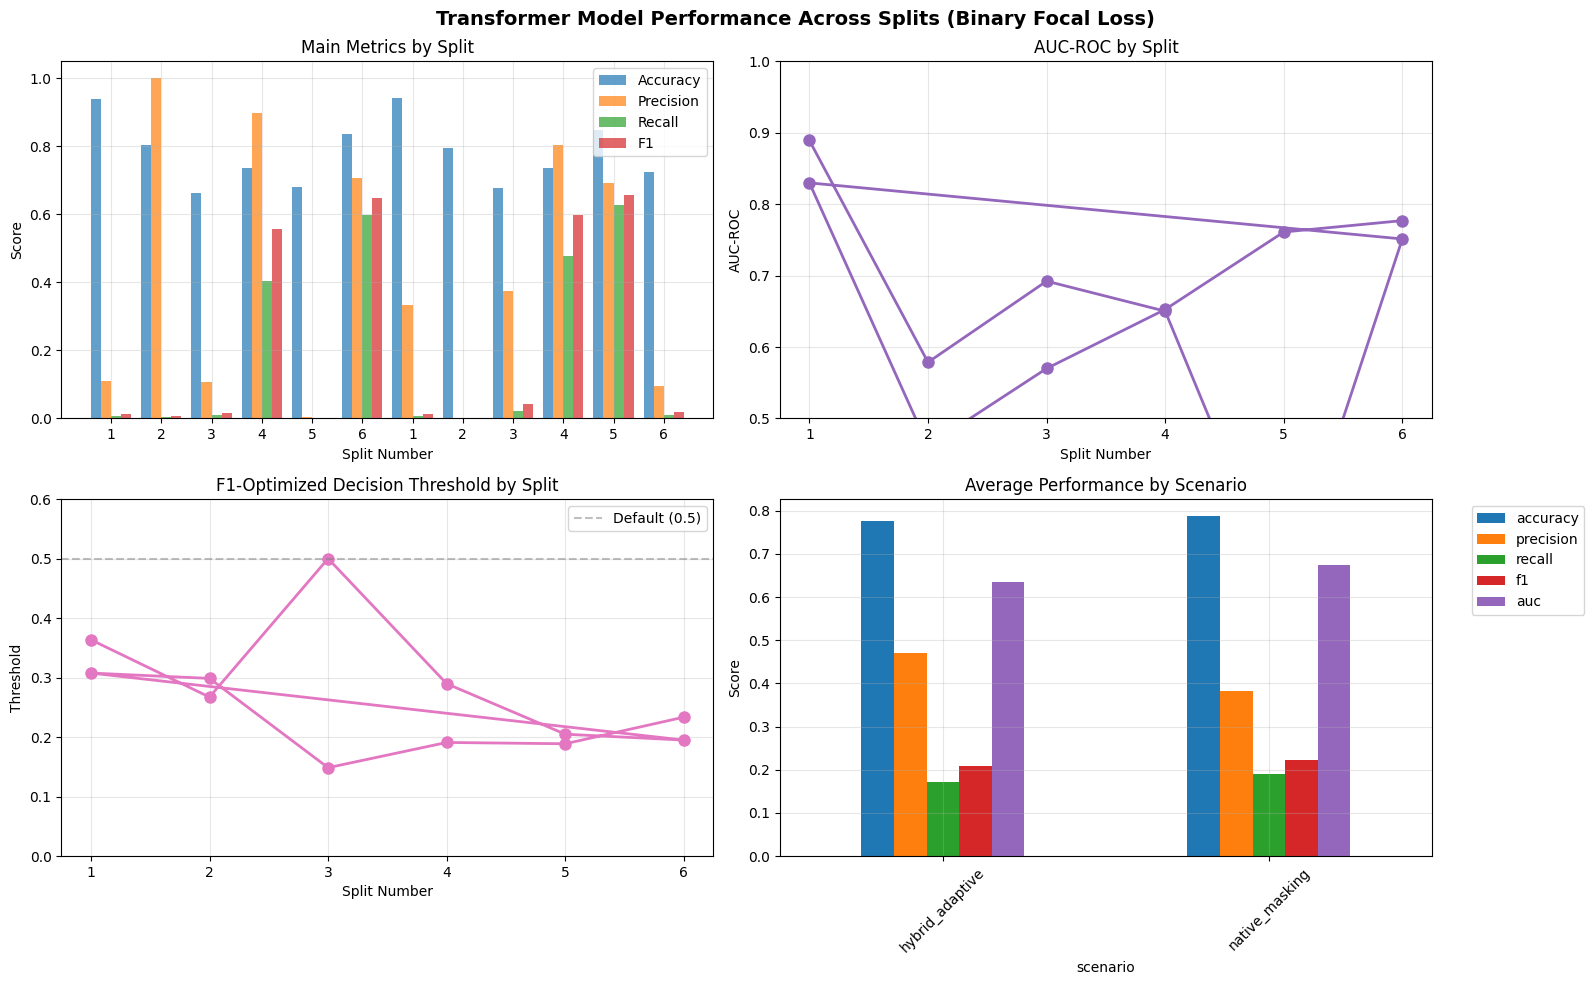


📄 Per-split metrics saved to: results\transformer_per_split_metrics.csv

  SUMMARY STATISTICS (Mean ± Std across splits)
  accuracy    :  0.7821 ±  0.0961
  precision   :  0.4271 ±  0.3726
  recall      :  0.1809 ±  0.2615
  f1          :  0.2150 ±  0.2972
  auc         :  0.6552 ±  0.1753
  threshold   :  0.2658 ±  0.0967


In [21]:
# ──────────────────────────────────────────────
# Cell 7 – Per-Split Results Analysis
# ──────────────────────────────────────────────

# Convert results to DataFrame for analysis
results_df = pd.DataFrame(all_results)

# Display per-split metrics table
print("═" * 100)
print("  PER-SPLIT METRICS (Binary Focal Loss + F1-Optimized Threshold)")
print("═" * 100)
display(results_df.round(4))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Transformer Model Performance Across Splits (Binary Focal Loss)', fontsize=14, fontweight='bold')

# Plot 1: Accuracy, Precision, Recall, F1 by split
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    values = results_df[metric]
    axes[0, 0].bar(x + i*width, values, width, label=metric.capitalize(),
                   color=colors[i], alpha=0.7)

axes[0, 0].set_title('Main Metrics by Split')
axes[0, 0].set_xlabel('Split Number')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_xticks(x + width*1.5)
axes[0, 0].set_xticklabels(results_df['split_num'])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: AUC-ROC by split
axes[0, 1].plot(results_df['split_num'], results_df['auc'], 'o-', color='#9467bd',
                linewidth=2, markersize=8)
axes[0, 1].set_title('AUC-ROC by Split')
axes[0, 1].set_xlabel('Split Number')
axes[0, 1].set_ylabel('AUC-ROC')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0.5, 1.0)

# Plot 3: Threshold values per split
axes[1, 0].plot(results_df['split_num'], results_df['threshold'], 'o-', color='#e377c2',
                linewidth=2, markersize=8)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[1, 0].set_title('F1-Optimized Decision Threshold by Split')
axes[1, 0].set_xlabel('Split Number')
axes[1, 0].set_ylabel('Threshold')
axes[1, 0].set_ylim(0.0, 0.6)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot 4: Scenario comparison (if multiple scenarios)
if len(results_df['scenario'].unique()) > 1:
    scenario_means = results_df.groupby('scenario')[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean()
    scenario_means.plot(kind='bar', ax=axes[1, 1], rot=45)
    axes[1, 1].set_title('Average Performance by Scenario')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 1].grid(True, alpha=0.3)
else:
    # If only one scenario, show distribution
    results_df[['accuracy', 'precision', 'recall', 'f1', 'auc']].boxplot(ax=axes[1, 1])
    axes[1, 1].set_title('Metric Distribution Across Splits')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save per-split metrics
per_split_csv = os.path.join(RESULTS_DIR, "transformer_per_split_metrics.csv")
results_df.to_csv(per_split_csv, index=False)
print(f"\n📄 Per-split metrics saved to: {per_split_csv}")

# Summary statistics
print(f"\n{'='*100}")
print("  SUMMARY STATISTICS (Mean ± Std across splits)")
print(f"{'='*100}")
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'threshold']
for col in metric_cols:
    mean = results_df[col].mean()
    std = results_df[col].std()
    print(f"  {col:12s}: {mean:7.4f} ± {std:7.4f}")

## 7 · Aggregate Metrics (Mean ± Std across splits)

In [22]:
# ──────────────────────────────────────────────
# Cell 8 – Aggregate reporting
# ──────────────────────────────────────────────

# Build summary statistics
METRICS = ["accuracy", "precision", "recall", "f1", "auc"]

def build_summary(per_split_df: pd.DataFrame) -> pd.DataFrame:
    agg = {m: ["mean", "std"] for m in METRICS}
    summary = per_split_df.groupby("scenario").agg(agg).round(6)
    summary.columns = [f"{a}_{b}" for a, b in summary.columns]
    summary = summary.reset_index()

    split_count = per_split_df.groupby("scenario")["split_num"].count().rename("n_splits").reset_index()
    summary = summary.merge(split_count, on="scenario", how="left")

    summary = summary.sort_values("auc_mean", ascending=False, na_position="last").reset_index(drop=True)
    summary.insert(0, "rank_auc", summary.index + 1)
    return summary

def build_pairwise_comparison(summary_df: pd.DataFrame) -> pd.DataFrame:
    """Create direct delta table (hybrid_adaptive - native_masking)."""
    req = {"hybrid_adaptive", "native_masking"}
    if not req.issubset(set(summary_df["scenario"])):
        return pd.DataFrame()

    left = summary_df.set_index("scenario").loc["hybrid_adaptive"]
    right = summary_df.set_index("scenario").loc["native_masking"]

    rows = []
    for metric in ["accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "auc_mean"]:
        rows.append(
            {
                "metric": metric.replace("_mean", ""),
                "hybrid_adaptive": left.get(metric),
                "native_masking": right.get(metric),
                "delta_hybrid_minus_native": left.get(metric) - right.get(metric),
            }
        )

    return pd.DataFrame(rows)

# Generate summaries
summary_df = build_summary(results_df)
pairwise_df = build_pairwise_comparison(summary_df)

# Display aggregate results
print("\n" + "═" * 80)
print("  AGGREGATE METRICS (Mean ± Std)")
print("═" * 80)

for _, row in summary_df.iterrows():
    scenario = row['scenario']
    print(f"\n🏆 {scenario.upper()}:")
    for metric in METRICS:
        mean_val = row[f"{metric}_mean"]
        std_val = row[f"{metric}_std"]
        print(f"   {metric.capitalize():10s}: {mean_val:.4f} ± {std_val:.4f}")

# Save summaries
summary_csv = os.path.join(RESULTS_DIR, "transformer_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print(f"\nSummary statistics saved to: {summary_csv}")

if not pairwise_df.empty:
    pairwise_csv = os.path.join(RESULTS_DIR, "transformer_hybrid_vs_native.csv")
    pairwise_df.to_csv(pairwise_csv, index=False)
    print(f"Pairwise comparison saved to: {pairwise_csv}")

    print("\nHybrid Adaptive vs Native Masking:")
    for _, row in pairwise_df.iterrows():
        metric_name = row['metric']
        delta = row['delta_hybrid_minus_native']
        direction = "🔺" if delta > 0 else "🔻" if delta < 0 else "➡️"
        print(f"   {metric_name.capitalize():10s}: {direction} {delta:+.4f}")

print("\n⏱️  Timing Summary:")
print(f"   • Total training time: {sum(training_times):.1f} seconds")
print(f"   • Average split time: {np.mean(training_times):.1f} seconds")
print(f"   • Total splits trained: {len(training_times)}")

print("\n✅ Transformer model training and evaluation complete!")
print("Results saved to transformer_model/results/")


════════════════════════════════════════════════════════════════════════════════
  AGGREGATE METRICS (Mean ± Std)
════════════════════════════════════════════════════════════════════════════════

🏆 NATIVE_MASKING:
   Accuracy  : 0.7877 ± 0.0957
   Precision : 0.3832 ± 0.3181
   Recall    : 0.1909 ± 0.2840
   F1        : 0.2224 ± 0.3156
   Auc       : 0.6753 ± 0.1406

🏆 HYBRID_ADAPTIVE:
   Accuracy  : 0.7766 ± 0.1052
   Precision : 0.4711 ± 0.4468
   Recall    : 0.1709 ± 0.2636
   F1        : 0.2077 ± 0.3076
   Auc       : 0.6350 ± 0.2165

Summary statistics saved to: results\transformer_summary.csv
Pairwise comparison saved to: results\transformer_hybrid_vs_native.csv

Hybrid Adaptive vs Native Masking:
   Accuracy  : 🔻 -0.0111
   Precision : 🔺 +0.0879
   Recall    : 🔻 -0.0200
   F1        : 🔻 -0.0147
   Auc       : 🔻 -0.0403

⏱️  Timing Summary:
   • Total training time: 1368.9 seconds
   • Average split time: 114.1 seconds
   • Total splits trained: 12

✅ Transformer model training 

## 8 · Save Final Models (trained on full data)

In [ ]:
# ──────────────────────────────────────────────
# Cell 9 – Retrain final model per scenario (full data) & save artefacts
# ──────────────────────────────────────────────

def make_full_sequence_dataset(scenario_df: pd.DataFrame, history_days: int = 30, horizon: int = 1) -> Dict[str, np.ndarray]:
    """Build full-history sequences (no train/test split) for final model retraining."""
    NON_FEATURE_COLS = {"Location_Name", "Date", "red_tide", "red_tide_label", "target_label"}

    feature_cols = [
        c for c in scenario_df.columns
        if c not in NON_FEATURE_COLS
        and c != "target_label"
        and pd.api.types.is_numeric_dtype(scenario_df[c])
    ]

    all_seq = []
    all_y = []

    for _, loc_df in scenario_df.groupby("Location_Name", sort=False):
        loc_df = loc_df.sort_values("Date").reset_index(drop=True)

        X = loc_df[feature_cols].to_numpy(dtype=np.float32)
        y = loc_df["target_label"].to_numpy(dtype=np.int64)

        for idx in range(len(loc_df)):
            start = idx - history_days + 1
            if start < 0:
                continue

            target_idx = idx + horizon
            if target_idx >= len(loc_df):
                continue

            seq = X[start : idx + 1]
            if seq.shape[0] != history_days:
                continue

            all_seq.append(seq)
            all_y.append(np.array([y[target_idx]], dtype=np.int64))

    if all_seq:
        X_all = np.stack(all_seq).astype(np.float32)
        y_all = np.concatenate(all_y).astype(np.int64)
    else:
        X_all = np.empty((0, history_days, len(feature_cols)), dtype=np.float32)
        y_all = np.empty((0,), dtype=np.int64)

    if X_all.shape[0] > 0:
        mean = np.nanmean(X_all, axis=(0, 1), keepdims=True)
        std = np.nanstd(X_all, axis=(0, 1), keepdims=True)
        std = np.where(std < 1e-8, 1.0, std)

        X_all = (X_all - mean) / std
        X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)
    else:
        mean = np.array([], dtype=np.float32)
        std = np.array([], dtype=np.float32)

    return {
        "X_all": X_all,
        "y_all": y_all,
        "feature_names": np.array(feature_cols),
        "norm_mean": mean,
        "norm_std": std,
    }

final_model_paths = {}

for scenario_name, scenario_df in SCENARIOS_DATA.items():
    print(f"Retraining final model for scenario: {scenario_name}")

    ds_full = make_full_sequence_dataset(
        scenario_df,
        history_days=HISTORY_DAYS,
        horizon=HORIZON,
    )

    X_all = ds_full["X_all"]
    y_all = ds_full["y_all"]

    if len(X_all) < 20:
        print(f"Skipped final save for {scenario_name}: insufficient samples ({len(X_all)}).")
        continue

    # Reuse training function and train on all sequences; test copy is only to satisfy the helper API.
    _, final_model = train_and_evaluate_split(
        X_all,
        y_all,
        X_all,
        y_all,
        config,
        random_seed=SEED,
        return_model=True,
    )

    if final_model is None:
        print(f"Skipped final save for {scenario_name}: training returned no model.")
        continue

    model_filename = f"haribon_transformer_{scenario_name}.pt"
    model_path = os.path.join(MODEL_DIR, model_filename)

    checkpoint = {
        "model_state_dict": final_model.state_dict(),
        "scenario": scenario_name,
        "history_days": int(HISTORY_DAYS),
        "horizon": int(HORIZON),
        "feature_names": ds_full["feature_names"].tolist(),
        "norm_mean": ds_full["norm_mean"],
        "norm_std": ds_full["norm_std"],
        "config": vars(config),
    }
    torch.save(checkpoint, model_path)

    final_model_paths[scenario_name] = model_path
    print(f"Saved final model → {model_path}")

print("\nFinal saved models:")
for k, v in final_model_paths.items():
    print(f"  {k}: {v}")

## 8 · Transformer Model Summary

In [24]:
# ──────────────────────────────────────────────
# Cell 10 – Final Model Summary
# ──────────────────────────────────────────────

print("TRANSFORMER MODEL FINAL SUMMARY")
print("=" * 50)

# Scenario performance table
perf_table = summary_df[['scenario', 'auc_mean', 'auc_std', 'accuracy_mean', 'accuracy_std']].copy()
perf_table.columns = ['Scenario', 'AUC Mean', 'AUC Std', 'Accuracy Mean', 'Accuracy Std']
perf_table = perf_table.round(4)
perf_table = perf_table.sort_values('AUC Mean', ascending=False).reset_index(drop=True)

print("\nPerformance by Scenario:")
display(perf_table)

# Split comparison table
split_compare_df = results_df[
    ['scenario', 'split_num', 'train_end', 'test_start', 'test_end', 'accuracy', 'precision', 'recall', 'f1', 'auc', 'train_time_sec']
].copy()
split_compare_df = split_compare_df.sort_values(['scenario', 'split_num']).reset_index(drop=True)
split_compare_df = split_compare_df.round(4)

print("\nSplit Comparison:")
display(split_compare_df)

best_row = split_compare_df.loc[split_compare_df['auc'].idxmax()]
print(
    f"\nBest Split by AUC: {best_row['scenario']} | "
    f"Split {int(best_row['split_num'])} | AUC {best_row['auc']:.4f}"
)

if 'final_model_paths' in globals() and len(final_model_paths) > 0:
    print("\nSaved final deployable models:")
    for scenario_name, model_path in final_model_paths.items():
        print(f"  {scenario_name}: {model_path}")

print(f"\nResults saved to: {RESULTS_DIR}/")
print(f"Model artefacts saved to: {MODEL_DIR}/")

TRANSFORMER MODEL FINAL SUMMARY

Performance by Scenario:


,Scenario,AUC Mean,AUC Std,Accuracy Mean,Accuracy Std
0,native_masking,0.6753,0.1406,0.7877,0.0957
1,hybrid_adaptive,0.6350,0.2164,0.7766,0.1052



Split Comparison:


,scenario,split_num,train_end,test_start,test_end,accuracy,precision,recall,f1,auc,train_time_sec
0,hybrid_adaptive,1,2019-12-31,2020-01-01,2020-12-31,0.9400,0.1111,0.0070,0.0132,0.8892,77.33
1,hybrid_adaptive,2,2020-12-31,2021-01-01,2021-12-31,0.8044,1.0000,0.0041,0.0081,0.5787,146.22
2,hybrid_adaptive,3,2021-12-31,2022-01-01,2022-12-31,0.6624,0.1061,0.0089,0.0165,0.6923,133.25
3,hybrid_adaptive,4,2022-12-31,2023-01-01,2023-12-31,0.7360,0.8987,0.4045,0.5579,0.6502,82.48
4,hybrid_adaptive,5,2023-12-31,2024-01-01,2024-12-31,0.6794,0.0046,0.0017,0.0025,0.2484,135.84
5,hybrid_adaptive,6,2024-12-31,2025-01-01,2026-12-31,0.8373,0.7059,0.5992,0.6482,0.7513,128.84
6,native_masking,1,2019-12-31,2020-01-01,2020-12-31,0.9424,0.3333,0.0070,0.0138,0.8298,91.24
7,native_masking,2,2020-12-31,2021-01-01,2021-12-31,0.7956,0.0000,0.0000,0.0000,0.4615,110.09
8,native_masking,3,2021-12-31,2022-01-01,2022-12-31,0.6785,0.3750,0.0230,0.0433,0.5699,102.01
9,native_masking,4,2022-12-31,2023-01-01,2023-12-31,0.7368,0.8039,0.4772,0.5989,0.6526,91.03



Best Split by AUC: hybrid_adaptive | Split 1 | AUC 0.8892

Results saved to: results/
Model artefacts saved to: saved_model/
